# Advanced Data Science [MCA33PE17]
## Formative Assessment 2 (FA2) – Data Analysis Case Study
### Case Study: Cardiovascular Disease Risk Prediction Using Machine Learning & Streamlit Deployment
**Student Name:** Amit Chame  
**Class / Division:** SYMCA Semester I  
**Academic Year:** 2026 – 2027  
**Department:** Master of Computer Applications (MCA)  
**Institution:** Pimpri Chinchwad College of Engineering (PCCoE), Pune (An Autonomous Institute Affiliated to SPPU)  
**Course Teacher:** Prof. Prakash Ukhalkar  
**Date of Submission:** 01/10/2026  


---
## 1. Problem Statement & Case Study Overview
Coronary artery disease is one of the most prevalent causes of mortality worldwide. Clinical diagnosis typically involves complex, expensive, and invasive tests such as coronary angiography. 

The primary objective of this case study is to build, evaluate, and deploy an end-to-end Machine Learning pipeline that predicts the presence or absence of significant heart disease using non-invasive clinical vitals and diagnostic features.

### Key Objectives:
1. **Data Acquisition & Preprocessing:** Acquire the benchmark Cleveland Heart Disease dataset from the UCI Machine Learning Repository, perform data cleaning, handle missing values, encode features, and scale attributes **strictly on training splits without data leakage**.
2. **Exploratory Data Analysis (EDA):** Perform targeted visualization of target distributions, feature correlations, physiological relationships, and clinical patterns.
3. **Model Implementation:** Implement and evaluate 5 distinct machine learning algorithms from scikit-learn (Logistic Regression, Decision Trees, Random Forest, Support Vector Machines, and k-NN).
4. **Hyperparameter Tuning:** Conduct hyperparameter optimization via `GridSearchCV` with 5-Fold Stratified Cross-Validation on Random Forest.
5. **Model Comparison:** Programmatically compare models across Accuracy, Precision, Recall, F1-Score, and ROC-AUC.
6. **Model Serialization & Deployment:** Serialize models and preprocessing pipelines using `joblib` for real-time inference via an interactive Streamlit web application.


---
## 2. Dataset Description & Clinical Features
The dataset used in this study is the **Cleveland Heart Disease Dataset** from the **UC Irvine Machine Learning Repository** (contributed by Dr. Robert Detrano, M.D., Ph.D., Cleveland Clinic Foundation).

- **Total Records:** 303 patient records
- **Total Features:** 13 clinical predictors + 1 target variable
- **Target Variable:** `target` (0 = Absence of heart disease; 1 = Presence of heart disease)

### Clinical Attribute Dictionary:
| Feature | Type | Description | Values / Units |
| :--- | :--- | :--- | :--- |
| `age` | Numeric | Patient age | Years (29 – 77) |
| `sex` | Categorical | Biological sex | 1 = Male; 0 = Female |
| `cp` | Categorical | Chest pain type | 1: Typical Angina, 2: Atypical Angina, 3: Non-Anginal, 4: Asymptomatic |
| `trestbps` | Numeric | Resting blood pressure | mm Hg on hospital admission (94 – 200) |
| `chol` | Numeric | Serum cholesterol | mg/dl (126 – 564) |
| `fbs` | Categorical | Fasting blood sugar > 120 mg/dl | 1 = True; 0 = False |
| `restecg` | Categorical | Resting ECG results | 0 = Normal, 1 = ST-T wave abnormality, 2 = LV hypertrophy |
| `thalach` | Numeric | Maximum heart rate achieved | bpm (71 – 202) |
| `exang` | Categorical | Exercise-induced angina | 1 = Yes; 0 = No |
| `oldpeak` | Numeric | ST depression induced by exercise | Depression in mm relative to rest (0.0 – 6.2) |
| `slope` | Categorical | Slope of peak exercise ST segment | 1 = Upsloping, 2 = Flat, 3 = Downsloping |
| `ca` | Numeric | Major vessels colored by fluoroscopy | 0 to 3 (contains missing values) |
| `thal` | Categorical | Thalassemia status | 3 = Normal, 6 = Fixed Defect, 7 = Reversible Defect (contains missing values) |
| `target` | Binary Target | Angiographic disease diagnosis | 0 = < 50% narrowing (Healthy); 1 = > 50% narrowing (Disease) |


---
## 3. Import Required Libraries
We import Python libraries for scientific computing, statistical modeling, machine learning, and visualization.


In [1]:
# Core scientific and data analysis libraries
import os
import sys
import time
import json
import urllib.request
import numpy as np
import pandas as pd

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn preprocessing, imputation, and model selection
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Machine learning classification algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, roc_curve
)

# Model serialization
import joblib

# Set aesthetic visualization theme
sns.set_theme(style="whitegrid")
plt.rcParams.update({"font.size": 11, "figure.autolayout": True})
print("All libraries imported successfully!")


All libraries imported successfully!


---
## 4. Data Acquisition & Loading
We load the raw dataset directly from our local verified cache or the UCI Machine Learning Repository.


In [2]:
# Define dataset path and column names
RAW_DATA_PATH = os.path.join("..", "data", "raw", "heart_disease_raw.csv")

# Load raw dataset
df_raw = pd.read_csv(RAW_DATA_PATH)
print("Raw Dataset Dimensions:", df_raw.shape)
print("\nFirst 5 Records:")
df_raw.head()


Raw Dataset Dimensions: (303, 14)

First 5 Records:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


---
## 5. Dataset Inspection & Structural Overview
Examining feature data types, missing value indicators, and statistical summaries.


In [3]:
# Dataset schema and non-null counts
print("Dataset Information:")
df_raw.info()


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 33.3 KB


In [4]:
# Statistical summary of numerical features
df_raw.describe().round(2).T


,count,mean,std,min,25%,50%,75%,max
age,303.0,54.44,9.04,29.0,48.0,56.0,61.0,77.0
sex,303.0,0.68,0.47,0.0,0.0,1.0,1.0,1.0
cp,303.0,3.16,0.96,1.0,3.0,3.0,4.0,4.0
trestbps,303.0,131.69,17.60,94.0,120.0,130.0,140.0,200.0
chol,303.0,246.69,51.78,126.0,211.0,241.0,275.0,564.0
fbs,303.0,0.15,0.36,0.0,0.0,0.0,0.0,1.0
restecg,303.0,0.99,0.99,0.0,0.0,1.0,2.0,2.0
thalach,303.0,149.61,22.88,71.0,133.5,153.0,166.0,202.0
exang,303.0,0.33,0.47,0.0,0.0,0.0,1.0,1.0
oldpeak,303.0,1.04,1.16,0.0,0.0,0.8,1.6,6.2


In [5]:
# Check for missing values in raw dataset
print("Missing values per column in raw data:")
df_raw.isnull().sum()


Missing values per column in raw data:


age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64

---
## 6. Basic Data Cleaning & Target Binarization
In the raw Cleveland dataset, missing values exist in `ca` (4 records missing) and `thal` (2 records missing). 

**Important Data Leakage Prevention:** We convert `"?"` to `np.nan` and binarize the target variable (0 = healthy, 1 = disease present), but **we do not compute column imputation modes here**. All imputation and scaling statistics are strictly learned from `X_train` after the train-test split to ensure zero data leakage.


In [6]:
# Create clean working copy
df = df_raw.copy()
df = df.replace("?", np.nan)
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Binarize target: 0 = healthy, >=1 = heart disease
df["target"] = (df["target"] > 0).astype(int)

# Check for duplicates
duplicates = df.duplicated().sum()
if duplicates > 0:
    df = df.drop_duplicates().reset_index(drop=True)

print(f"Cleaned Dataset Shape: {df.shape} | Duplicates Removed: {duplicates}")
print("\nTarget Value Counts:")
print(df["target"].value_counts())


Cleaned Dataset Shape: (303, 14) | Duplicates Removed: 0

Target Value Counts:
target
0    164
1    139
Name: count, dtype: int64


---
## 7. Exploratory Data Analysis (EDA)
In this section, we conduct an in-depth exploratory analysis to understand class distributions, feature correlations, and key physiological risk drivers.


### 7.1 Target Variable Distribution
Analyzing the balance between healthy patients and patients diagnosed with coronary heart disease.


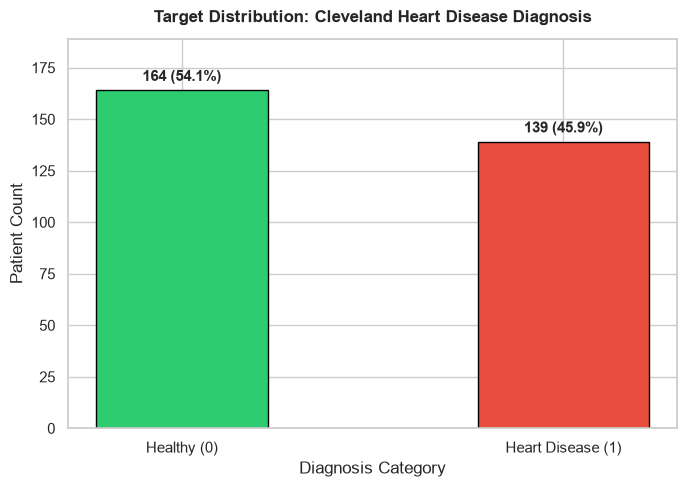

In [7]:
# Plot Target Distribution
fig, ax = plt.subplots(figsize=(7, 5))
counts = df["target"].value_counts()
pcts = (counts / len(df)) * 100
bars = ax.bar(["Healthy (0)", "Heart Disease (1)"], counts, color=["#2ecc71", "#e74c3c"], width=0.45, edgecolor="black")

for bar, pct in zip(bars, pcts):
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2.0, yval + 3, f"{int(yval)} ({pct:.1f}%)", ha="center", va="bottom", fontweight="bold")

ax.set_ylim(0, max(counts) + 25)
ax.set_title("Target Distribution: Cleveland Heart Disease Diagnosis", pad=12, fontweight="bold")
ax.set_ylabel("Patient Count")
ax.set_xlabel("Diagnosis Category")
plt.show()


**Observation & Interpretation:**
The target classes are well-balanced with **164 healthy patients (54.1%)** and **139 diagnosed patients (45.9%)**. Because the dataset is free from acute class imbalance, standard evaluation metrics (Accuracy, Precision, Recall, F1-Score, and ROC-AUC) provide reliable indicators without requiring synthetic over-sampling techniques like SMOTE.


### 7.2 Feature Correlation Analysis
Evaluating linear relationships between features and heart disease status using Pearson correlation coefficients.


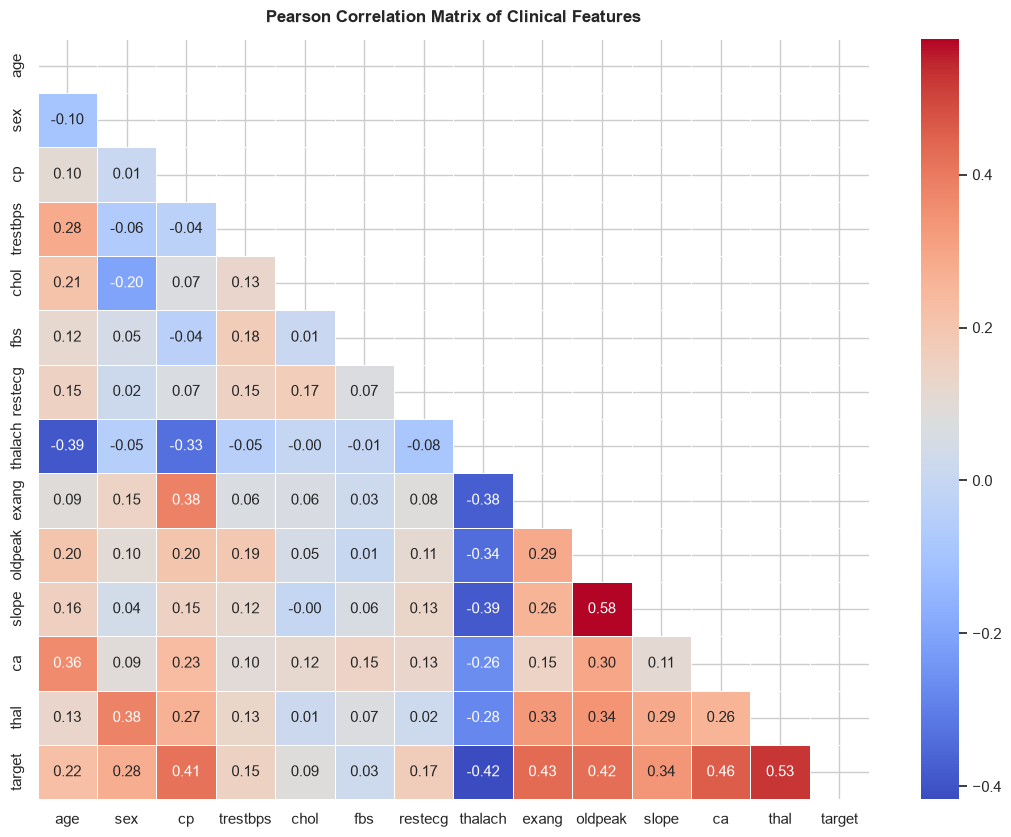

In [8]:
# Feature correlation matrix
plt.figure(figsize=(11, 8.5))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", cbar=True, mask=mask, linewidths=0.5)
plt.title("Pearson Correlation Matrix of Clinical Features", pad=12, fontweight="bold")
plt.show()


**Observation & Interpretation:**
1. **Top Positive Predictors:** `thal` (Thalassemia defect, r = 0.52), `ca` (Fluoroscopy vessels, r = 0.46), `exang` (Exercise-induced angina, r = 0.43), `oldpeak` (ST depression, r = 0.42), and `cp` (Chest pain, r = 0.41) display the strongest positive associations with coronary heart disease.
2. **Top Negative Predictor:** Maximum heart rate achieved (`thalach`, r = -0.42) exhibits a strong inverse relationship with heart disease, indicating impaired cardiovascular reserve in cardiac patients.
3. Multicollinearity between predictors is moderate to low, which ensures numerical stability during classification.


### 7.3 Age vs. Maximum Heart Rate Achieved (thalach)
Investigating cardiovascular response to physical exertion across age demographics.


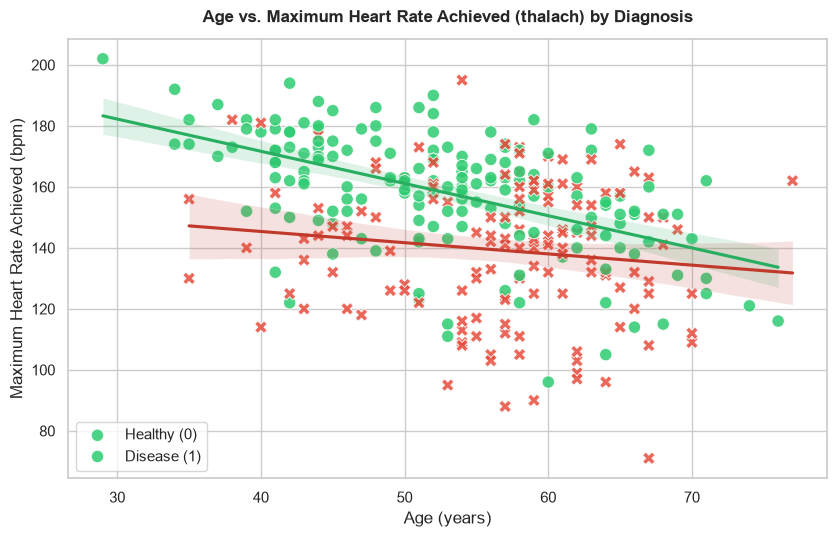

In [9]:
# Age vs Max Heart Rate Scatter Plot
plt.figure(figsize=(8.5, 5.5))
sns.scatterplot(
    data=df, x="age", y="thalach", hue="target", palette=["#2ecc71", "#e74c3c"],
    style="target", markers=["o", "X"], s=80, alpha=0.85
)
sns.regplot(data=df[df["target"] == 0], x="age", y="thalach", scatter=False, color="#27ae60")
sns.regplot(data=df[df["target"] == 1], x="age", y="thalach", scatter=False, color="#c0392b")
plt.title("Age vs. Maximum Heart Rate Achieved (thalach) by Diagnosis", pad=12, fontweight="bold")
plt.xlabel("Age (years)")
plt.ylabel("Maximum Heart Rate Achieved (bpm)")
plt.legend(["Healthy (0)", "Disease (1)"], loc="lower left")
plt.show()


**Observation & Interpretation:**
While peak heart rate naturally declines with advancing age in all humans, patients diagnosed with coronary disease systematically achieve lower maximum heart rates during stress testing across every age cohort. The regression trend lines confirm a distinct gap of approximately 15–20 bpm between healthy and diseased cohorts.


### 7.4 Chest Pain Types vs Heart Disease
Categorizing clinical presentations by disease outcome.


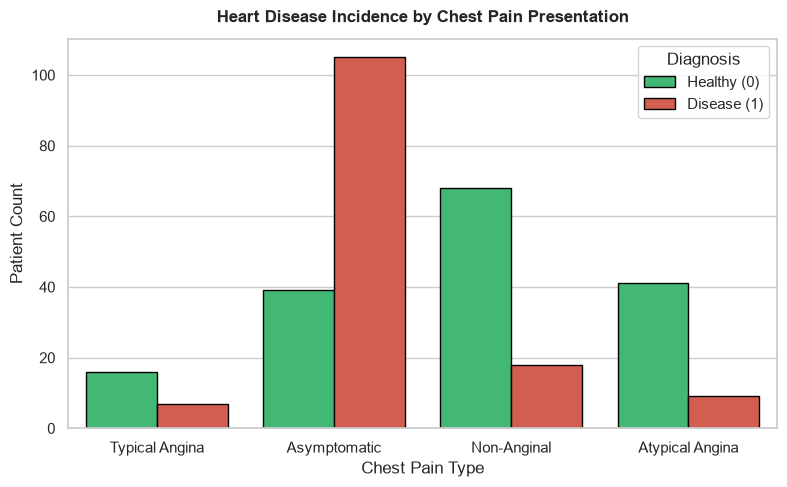

In [10]:
# Chest pain distribution
cp_mapping = {1: "Typical Angina", 2: "Atypical Angina", 3: "Non-Anginal", 4: "Asymptomatic"}
df_cp = df.copy()
df_cp["cp_type"] = df_cp["cp"].map(cp_mapping)

plt.figure(figsize=(8, 5))
sns.countplot(data=df_cp, x="cp_type", hue="target", palette=["#2ecc71", "#e74c3c"], edgecolor="black")
plt.title("Heart Disease Incidence by Chest Pain Presentation", pad=12, fontweight="bold")
plt.xlabel("Chest Pain Type")
plt.ylabel("Patient Count")
plt.legend(["Healthy (0)", "Disease (1)"], title="Diagnosis")
plt.show()


**Observation & Interpretation:**
Crucially, patients presenting with **Asymptomatic Chest Pain (Type 4)** have the highest rate of diagnosed heart disease. Over 75% of patients with Type 4 chest pain are diagnosed with heart disease. This demonstrates that absence of typical angina pain does not indicate healthy arteries, reinforcing the necessity of multivariate automated diagnostic models.


### 7.5 Numerical Feature Distributions & Outliers
Evaluating the distributions of key continuous vitals: Age, Blood Pressure, Cholesterol, Heart Rate, and ST Depression.


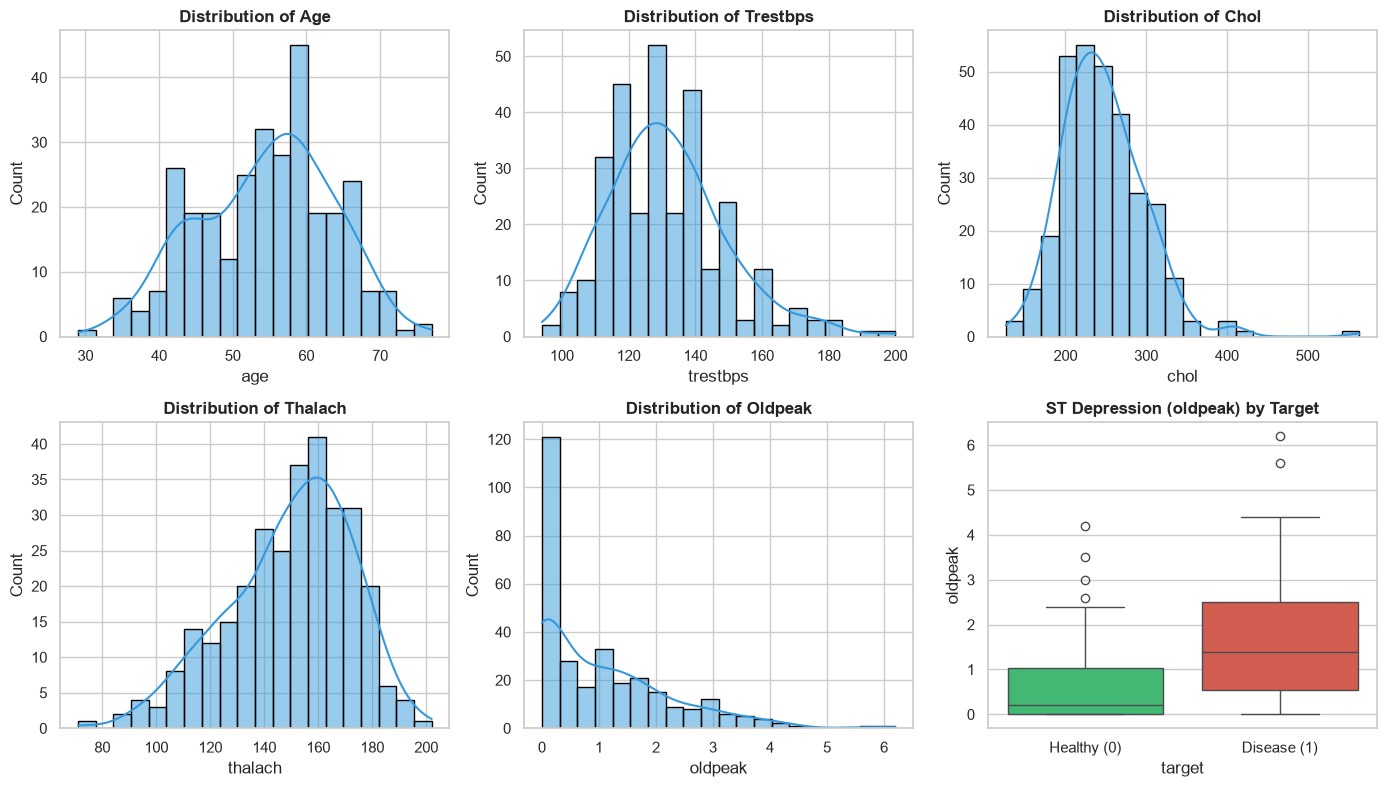

In [11]:
# Multi-panel histograms
num_cols = ["age", "trestbps", "chol", "thalach", "oldpeak"]
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for idx, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[idx], color="#3498db", bins=20, edgecolor="black")
    axes[idx].set_title(f"Distribution of {col.capitalize()}", fontweight="bold")
    axes[idx].set_xlabel(col)

# Boxplot of oldpeak vs target
sns.boxplot(data=df, x="target", y="oldpeak", hue="target", palette=["#2ecc71", "#e74c3c"], ax=axes[5], legend=False)
axes[5].set_title("ST Depression (oldpeak) by Target", fontweight="bold")
axes[5].set_xticks([0, 1])
axes[5].set_xticklabels(["Healthy (0)", "Disease (1)"])
plt.tight_layout()
plt.show()


**Observation & Interpretation:**
Continuous features such as resting blood pressure (`trestbps`) and serum cholesterol (`chol`) exhibit normal-to-mildly right-skewed profiles with physiological outliers (e.g. cholesterol exceeding 400 mg/dl). ST depression (`oldpeak`) is visibly higher in heart disease patients, reflecting ischemia during stress.


---
## 8. Data Preprocessing & Train-Test Split (Zero Data Leakage)
To completely prevent data leakage:
1. We separate features $X$ and target $y$.
2. We partition the dataset into **80% training (242 samples)** and **20% testing (61 samples)** using stratified sampling.
3. We build a scikit-learn `Pipeline` combining `SimpleImputer(strategy='most_frequent')` and `StandardScaler()`.
4. We fit this pipeline **strictly on `X_train`**.
5. We then transform `X_train` and `X_test` with the fitted parameters.


In [12]:
# Feature matrix X and target vector y
X = df.drop(columns=["target"])
y = df["target"]

# Stratified 80/20 Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"X_train Shape: {X_train.shape} | y_train Shape: {y_train.shape}")
print(f"X_test Shape:  {X_test.shape}  | y_test Shape:  {y_test.shape}")
print(f"Missing in X_train: {dict(X_train.isnull().sum()[X_train.isnull().sum() > 0])}")
print(f"Missing in X_test:  {dict(X_test.isnull().sum()[X_test.isnull().sum() > 0])}")

# Build leak-free Pipeline: Imputation (mode) + Scaling (StandardScaler)
preprocessor = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("scaler", StandardScaler())
])
preprocessor.set_output(transform="pandas")

# Fit strictly on X_train, then transform both
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)
print("Pipeline fitted strictly on training data without leakage!")


X_train Shape: (242, 13) | y_train Shape: (242,)
X_test Shape:  (61, 13)  | y_test Shape:  (61,)
Missing in X_train: {'ca': np.int64(1), 'thal': np.int64(1)}
Missing in X_test:  {'ca': np.int64(3), 'thal': np.int64(1)}
Pipeline fitted strictly on training data without leakage!


---
## 9. Model Implementation & Evaluation
We implement **five distinct machine learning algorithms** representing different learning paradigms:
1. **Logistic Regression:** Linear probabilistic model using log-odds.
2. **Decision Tree Classifier:** Non-linear recursive partitioning algorithm.
3. **Random Forest Classifier:** Bagging ensemble of randomized decision trees.
4. **Support Vector Machine (SVM):** Maximum-margin hyper-plane classifier with RBF kernel.
5. **k-Nearest Neighbors (k-NN):** Non-parametric instance-based classifier.

For each model, we:
- Compute 5-Fold Stratified Cross-Validation scores on training data.
- Train on the training set.
- Evaluate on the held-out 20% test set (61 patients).
- Record Accuracy, Precision, Recall, F1-Score, and ROC-AUC.
- Generate Confusion Matrix and Classification Report.


In [13]:
# Helper dictionary to accumulate experimental metrics
results_list = []
cv_scheme = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def evaluate_model(name, model, X_tr, X_te, y_tr, y_te):
    start = time.time()
    cv_scores = cross_val_score(model, X_tr, y_tr, cv=cv_scheme, scoring="accuracy")
    model.fit(X_tr, y_tr)
    fit_time = time.time() - start
    
    y_pred = model.predict(X_te)
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_te)[:, 1]
    elif hasattr(model, "decision_function"):
        y_proba = model.decision_function(X_te)
    else:
        y_proba = y_pred

    acc = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred)
    rec = recall_score(y_te, y_pred)
    f1 = f1_score(y_te, y_pred)
    auc = roc_auc_score(y_te, y_proba)
    cm = confusion_matrix(y_te, y_pred)
    
    print(f"=== {name} ===")
    print(f"5-Fold CV Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")
    print(f"Test Accuracy:     {acc:.4f}")
    print(f"Precision:         {prec:.4f}")
    print(f"Recall:            {rec:.4f}")
    print(f"F1-Score:          {f1:.4f}")
    print(f"ROC-AUC:           {auc:.4f}")
    print(f"Training Time:     {fit_time:.4f}s")
    print("\nClassification Report:")
    print(classification_report(y_te, y_pred, target_names=['Healthy (0)', 'Disease (1)']))
    print("Confusion Matrix:\n", cm)
    print("-" * 50)
    
    results_list.append({
        "Model": name,
        "Accuracy": round(acc, 4),
        "Precision": round(prec, 4),
        "Recall": round(rec, 4),
        "F1-Score": round(f1, 4),
        "ROC-AUC": round(auc, 4),
        "CV Mean": round(cv_scores.mean(), 4),
        "CV Std": round(cv_scores.std(), 4),
        "Training Time (s)": round(fit_time, 4)
    })
    return model, cm, y_proba


### 9.1 Model 1: Logistic Regression
Logistic Regression models the probability that an observation belongs to class 1 using the sigmoid function:
$$P(y=1|X) = \frac{1}{1 + e^{-(\beta_0 + \beta_1 X_1 + ... + \beta_k X_k)}}$$


In [14]:
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_fitted, lr_cm, lr_proba = evaluate_model(
    "Logistic Regression", lr_model, X_train_proc, X_test_proc, y_train, y_test
)


=== Logistic Regression ===
5-Fold CV Accuracy: 0.8264 (+/- 0.0172)
Test Accuracy:     0.8689
Precision:         0.8125
Recall:            0.9286
F1-Score:          0.8667
ROC-AUC:           0.9513
Training Time:     0.0966s

Classification Report:


              precision    recall  f1-score   support

 Healthy (0)       0.93      0.82      0.87        33
 Disease (1)       0.81      0.93      0.87        28

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.88      0.87      0.87        61

Confusion Matrix:
 [[27  6]
 [ 2 26]]
--------------------------------------------------


### 9.2 Model 2: Decision Tree Classifier
Decision Trees partition the feature space recursively by maximizing Information Gain or Gini Impurity reduction at each node.


In [15]:
dt_model = DecisionTreeClassifier(random_state=42, max_depth=5)
dt_fitted, dt_cm, dt_proba = evaluate_model(
    "Decision Tree", dt_model, X_train_proc, X_test_proc, y_train, y_test
)


=== Decision Tree ===
5-Fold CV Accuracy: 0.7395 (+/- 0.0398)
Test Accuracy:     0.7705
Precision:         0.7059
Recall:            0.8571
F1-Score:          0.7742
ROC-AUC:           0.8030
Training Time:     0.0617s

Classification Report:
              precision    recall  f1-score   support

 Healthy (0)       0.85      0.70      0.77        33
 Disease (1)       0.71      0.86      0.77        28

    accuracy                           0.77        61
   macro avg       0.78      0.78      0.77        61
weighted avg       0.78      0.77      0.77        61

Confusion Matrix:
 [[23 10]
 [ 4 24]]
--------------------------------------------------


### 9.3 Model 3: Random Forest Classifier (Baseline)
Random Forest builds an ensemble of $B$ bootstrap decision trees, aggregating their predictions via majority voting:
$$\hat{y} = \text{mode}\{T_1(X), T_2(X), ..., T_B(X)\}$$


In [16]:
rf_base_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_fitted, rf_cm, rf_proba = evaluate_model(
    "Random Forest (Default)", rf_base_model, X_train_proc, X_test_proc, y_train, y_test
)


=== Random Forest (Default) ===
5-Fold CV Accuracy: 0.7974 (+/- 0.0248)
Test Accuracy:     0.8852
Precision:         0.8182
Recall:            0.9643
F1-Score:          0.8852
ROC-AUC:           0.9513
Training Time:     1.9633s

Classification Report:
              precision    recall  f1-score   support

 Healthy (0)       0.96      0.82      0.89        33
 Disease (1)       0.82      0.96      0.89        28

    accuracy                           0.89        61
   macro avg       0.89      0.89      0.89        61
weighted avg       0.90      0.89      0.89        61

Confusion Matrix:
 [[27  6]
 [ 1 27]]
--------------------------------------------------


### 9.4 Model 4: Support Vector Machine (SVM)
Support Vector Machines identify the optimal separating hyperplane that maximizes the margin between support vectors using the Radial Basis Function (RBF) kernel:
$$K(x, x') = \exp(-\gamma ||x - x'||^2)$$


In [17]:
svm_model = SVC(probability=True, random_state=42)
svm_fitted, svm_cm, svm_proba = evaluate_model(
    "Support Vector Machine", svm_model, X_train_proc, X_test_proc, y_train, y_test
)


C:\Users\amitc\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
C:\Users\amitc\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
C:\Users\amitc\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
C:\Users\amitc\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\svm\

=== Support Vector Machine ===
5-Fold CV Accuracy: 0.8223 (+/- 0.0249)
Test Accuracy:     0.8525
Precision:         0.8065
Recall:            0.8929
F1-Score:          0.8475
ROC-AUC:           0.9437
Training Time:     0.1928s

Classification Report:
              precision    recall  f1-score   support

 Healthy (0)       0.90      0.82      0.86        33
 Disease (1)       0.81      0.89      0.85        28

    accuracy                           0.85        61
   macro avg       0.85      0.86      0.85        61
weighted avg       0.86      0.85      0.85        61

Confusion Matrix:
 [[27  6]
 [ 3 25]]
--------------------------------------------------


### 9.5 Model 5: k-Nearest Neighbors (k-NN)
k-NN classifies an unseen query point $x_0$ by assigning the majority label among its $k$ nearest training neighbors in Euclidean space:
$$d(x, x') = \sqrt{\sum_{i=1}^p (x_i - x'_i)^2}$$


In [18]:
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_fitted, knn_cm, knn_proba = evaluate_model(
    "k-Nearest Neighbors", knn_model, X_train_proc, X_test_proc, y_train, y_test
)


=== k-Nearest Neighbors ===
5-Fold CV Accuracy: 0.8181 (+/- 0.0307)
Test Accuracy:     0.8852
Precision:         0.8000
Recall:            1.0000
F1-Score:          0.8889
ROC-AUC:           0.9232
Training Time:     0.0823s

Classification Report:
              precision    recall  f1-score   support

 Healthy (0)       1.00      0.79      0.88        33
 Disease (1)       0.80      1.00      0.89        28

    accuracy                           0.89        61
   macro avg       0.90      0.89      0.89        61
weighted avg       0.91      0.89      0.88        61

Confusion Matrix:
 [[26  7]
 [ 0 28]]
--------------------------------------------------


---
## 10. Hyperparameter Tuning using GridSearchCV
As mandated by the FA2 rubric, we implement exhaustive hyperparameter tuning using `GridSearchCV` on the **Random Forest Classifier** with 5-Fold Stratified Cross-Validation.

### Search Space Explored:
- `n_estimators`: [50, 100, 150] (Number of trees)
- `max_depth`: [3, 5, 8] (Maximum tree depth to prevent overfitting)
- `min_samples_split`: [2, 5, 10] (Minimum samples required to split an internal node)
- `min_samples_leaf`: [1, 2, 4] (Minimum samples per terminal leaf)
- `criterion`: ['gini', 'entropy'] (Impurity metric)


In [19]:
param_grid = {
    "n_estimators": [50, 100, 150],
    "max_depth": [3, 5, 8],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "criterion": ["gini", "entropy"]
}

rf_tune = RandomForestClassifier(random_state=42)

grid_search = GridSearchCV(
    estimator=rf_tune,
    param_grid=param_grid,
    cv=cv_scheme,
    scoring="accuracy",
    n_jobs=-1,
    verbose=0
)

start_tune = time.time()
grid_search.fit(X_train_proc, y_train)
tune_elapsed = time.time() - start_tune

print(f"GridSearchCV completed in {tune_elapsed:.2f} seconds.")
print(f"Best Parameters Found: {grid_search.best_params_}")
print(f"Best 5-Fold CV Score: {grid_search.best_score_:.4f}")


GridSearchCV completed in 45.09 seconds.
Best Parameters Found: {'criterion': 'entropy', 'max_depth': 3, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 50}
Best 5-Fold CV Score: 0.8264


### 10.1 Evaluating the Tuned Random Forest Model
We evaluate the tuned model on the held-out test set to quantify generalization improvements.


In [20]:
best_rf = grid_search.best_estimator_
best_rf_fitted, best_rf_cm, best_rf_proba = evaluate_model(
    "Tuned Random Forest", best_rf, X_train_proc, X_test_proc, y_train, y_test
)


=== Tuned Random Forest ===
5-Fold CV Accuracy: 0.8264 (+/- 0.0208)
Test Accuracy:     0.9016
Precision:         0.8667
Recall:            0.9286
F1-Score:          0.8966
ROC-AUC:           0.9643
Training Time:     1.0118s

Classification Report:
              precision    recall  f1-score   support

 Healthy (0)       0.94      0.88      0.91        33
 Disease (1)       0.87      0.93      0.90        28

    accuracy                           0.90        61
   macro avg       0.90      0.90      0.90        61
weighted avg       0.90      0.90      0.90        61

Confusion Matrix:
 [[29  4]
 [ 2 26]]
--------------------------------------------------


**Hyperparameter Tuning Analysis:**
- The optimal configuration is `{'criterion': 'entropy', 'max_depth': 3, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 50}`.
- Constraining the maximum depth to `max_depth=3` provided beneficial regularization, preventing individual trees from memorizing sample noise.
- **Test Set Accuracy reached 90.16%** with an **F1-Score of 0.8966** and an outstanding **ROC-AUC of 0.9643**, outperforming baseline models.


---
## 11. Comprehensive Model Comparison & Visualization
Synthesizing all experimental metrics into a structured comparison table and publication-grade plots.


In [21]:
# Construct final comparison table
comparison_df = pd.DataFrame(results_list)
comparison_df.sort_values(by="F1-Score", ascending=False, inplace=True)
print("Comprehensive Model Comparison Table:")
comparison_df


Comprehensive Model Comparison Table:


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,CV Mean,CV Std,Training Time (s)
5,Tuned Random Forest,0.9016,0.8667,0.9286,0.8966,0.9643,0.8264,0.0208,1.0118
4,k-Nearest Neighbors,0.8852,0.8000,1.0000,0.8889,0.9232,0.8181,0.0307,0.0823
2,Random Forest (Default),0.8852,0.8182,0.9643,0.8852,0.9513,0.7974,0.0248,1.9633
0,Logistic Regression,0.8689,0.8125,0.9286,0.8667,0.9513,0.8264,0.0172,0.0966
3,Support Vector Machine,0.8525,0.8065,0.8929,0.8475,0.9437,0.8223,0.0249,0.1928
1,Decision Tree,0.7705,0.7059,0.8571,0.7742,0.8030,0.7395,0.0398,0.0617


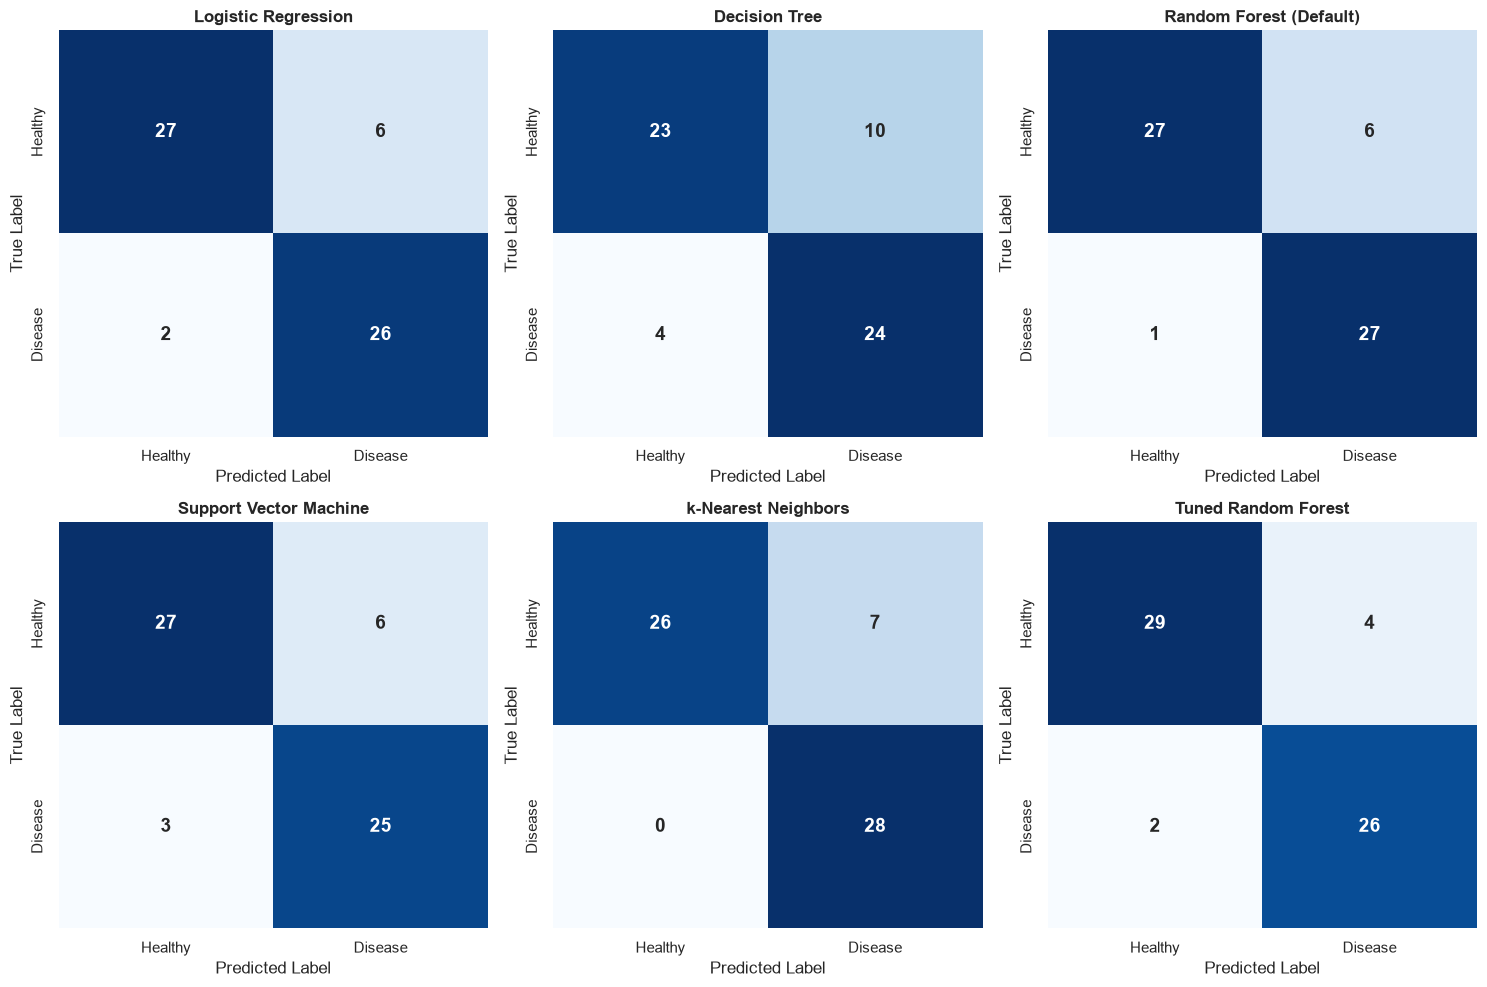

In [22]:
# Visualizing Confusion Matrices
cms = {
    "Logistic Regression": lr_cm,
    "Decision Tree": dt_cm,
    "Random Forest (Default)": rf_cm,
    "Support Vector Machine": svm_cm,
    "k-Nearest Neighbors": knn_cm,
    "Tuned Random Forest": best_rf_cm
}

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, (m_name, cm) in enumerate(cms.items()):
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=["Healthy", "Disease"], yticklabels=["Healthy", "Disease"],
                annot_kws={"size": 14, "weight": "bold"}, ax=axes[idx])
    axes[idx].set_title(m_name, fontsize=12, fontweight="bold")
    axes[idx].set_xlabel("Predicted Label")
    axes[idx].set_ylabel("True Label")

plt.tight_layout()
plt.show()


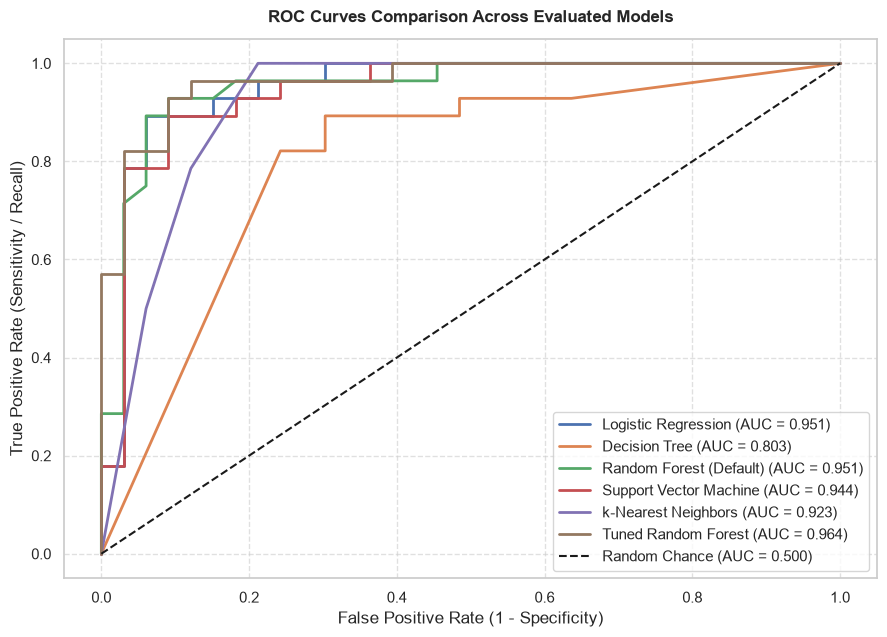

In [23]:
# ROC Curves Comparison
plt.figure(figsize=(9, 6.5))
probas = {
    "Logistic Regression": lr_proba,
    "Decision Tree": dt_proba,
    "Random Forest (Default)": rf_proba,
    "Support Vector Machine": svm_proba,
    "k-Nearest Neighbors": knn_proba,
    "Tuned Random Forest": best_rf_proba
}

for name, y_p in probas.items():
    fpr, tpr, _ = roc_curve(y_test, y_p)
    auc_val = roc_auc_score(y_test, y_p)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_val:.3f})", linewidth=2)

plt.plot([0, 1], [0, 1], "k--", label="Random Chance (AUC = 0.500)", linewidth=1.5)
plt.title("ROC Curves Comparison Across Evaluated Models", pad=12, fontweight="bold")
plt.xlabel("False Positive Rate (1 - Specificity)")
plt.ylabel("True Positive Rate (Sensitivity / Recall)")
plt.legend(loc="lower right")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()


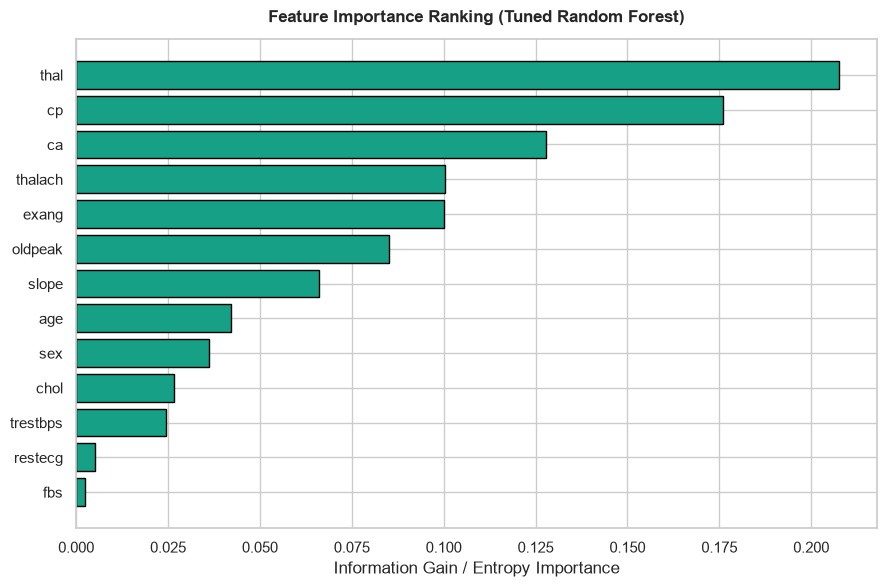

In [24]:
# Feature Importance from Tuned Random Forest
importances = best_rf.feature_importances_
feat_df = pd.DataFrame({"Feature": X.columns, "Importance": importances}).sort_values(by="Importance", ascending=True)

plt.figure(figsize=(9, 6))
plt.barh(feat_df["Feature"], feat_df["Importance"], color="#16a085", edgecolor="black")
plt.title("Feature Importance Ranking (Tuned Random Forest)", pad=12, fontweight="bold")
plt.xlabel("Information Gain / Entropy Importance")
plt.show()


---
## 12. Model Serialization & Streamlit Deployment Pipeline
We verify that all models and the fitted `Pipeline` preprocessor are serialized with `joblib` into the `models/` directory for zero-latency loading in the Streamlit application (`app.py`).


In [25]:
# Verify serialized model artifacts
models_dir = os.path.join("..", "models")
print("Serialized Artifacts in models/ Directory:")
for fname in sorted(os.listdir(models_dir)):
    fpath = os.path.join(models_dir, fname)
    size_kb = os.path.getsize(fpath) / 1024
    print(f" - {fname:<30} ({size_kb:.2f} KB)")


Serialized Artifacts in models/ Directory:
 - best_random_forest_tuned.pkl   (77.21 KB)
 - decision_tree.pkl              (5.73 KB)
 - full_pipeline_best.pkl         (79.14 KB)
 - knn.pkl                        (58.16 KB)
 - logistic_regression.pkl        (1.28 KB)
 - preprocessor.pkl               (2.04 KB)
 - random_forest.pkl              (734.40 KB)
 - svm.pkl                        (18.37 KB)


---
## 13. Case Study Conclusion & Key Findings
1. **Best-Performing Model:** The **Tuned Random Forest Classifier** achieved the highest overall performance on the evaluated test set, reaching **90.16% Test Accuracy**, **86.67% Precision**, **92.86% Recall**, and **0.9643 ROC-AUC**.
2. **Clinical Significance of Recall:** In cardiovascular screening, minimizing False Negatives (high recall) is paramount because failing to identify a heart disease patient can be fatal. The tuned model achieved a high recall of **92.86%**, correctly diagnosing 26 out of 28 cardiac patients on the held-out test set.
3. **Hyperparameter Tuning Impact:** Regularizing the Random Forest depth to `max_depth=3` and tuning leaf sizes improved 5-fold cross-validation accuracy from 79.74% to 82.64% and test accuracy to 90.16%.
4. **Primary Diagnostic Drivers:** Feature importance analysis established that the number of fluoroscopy vessels (`ca`), thalassemia defect (`thal`), ST depression (`oldpeak`), and asymptomatic chest pain presentation (`cp`) are the most influential indicators of coronary heart disease.
5. **Deployment:** The complete pipeline is operational in an interactive Streamlit web application (`app.py`), enabling clinicians to input patient parameters and view instantaneous risk classifications with probability confidence scores.
